**1. Identifying Data Types**

The dataset contains both categorical descriptions and numerical values, categorized as follows:

Quantitative Data (Numerical): work_year, salary, salary_in_usd, and remote_ratio. These represent measurable quantities.

Qualitative Data (Categorical): experience_level, employment_type, job_title, salary_currency, employee_residence, company_location, and company_size. These represent labels and attributes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Import the dataset
df = pd.read_csv('ds_salaries.csv')

missing_values = df.isnull().sum()
print("\nMissing values per column:\n", missing_values)

duplicates_count = df.duplicated().sum()
print(f"\nNumber of duplicates found: {duplicates_count}")

# Suppression des doublons si nécessaire
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Missing values per column:
 Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Number of duplicates found: 0


In [2]:
# Handling inconsistent labels for visualization
exp_map = {
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive-level'
}
df['experience_level_label'] = df['experience_level'].map(exp_map)

# Calculate mean and median for each experience level
salary_stats = df.groupby('experience_level_label')['salary_in_usd'].agg(['mean', 'median'])

# Sort levels logically
ordered_levels = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
salary_stats = salary_stats.reindex(ordered_levels)

print("Salary Statistics by Experience Level:")
print(salary_stats)

Salary Statistics by Experience Level:
                                 mean    median
experience_level_label                         
Entry-level              61643.318182   56500.0
Mid-level                87996.056338   76940.0
Senior-level            138617.292857  135500.0
Executive-level         199392.038462  171437.5


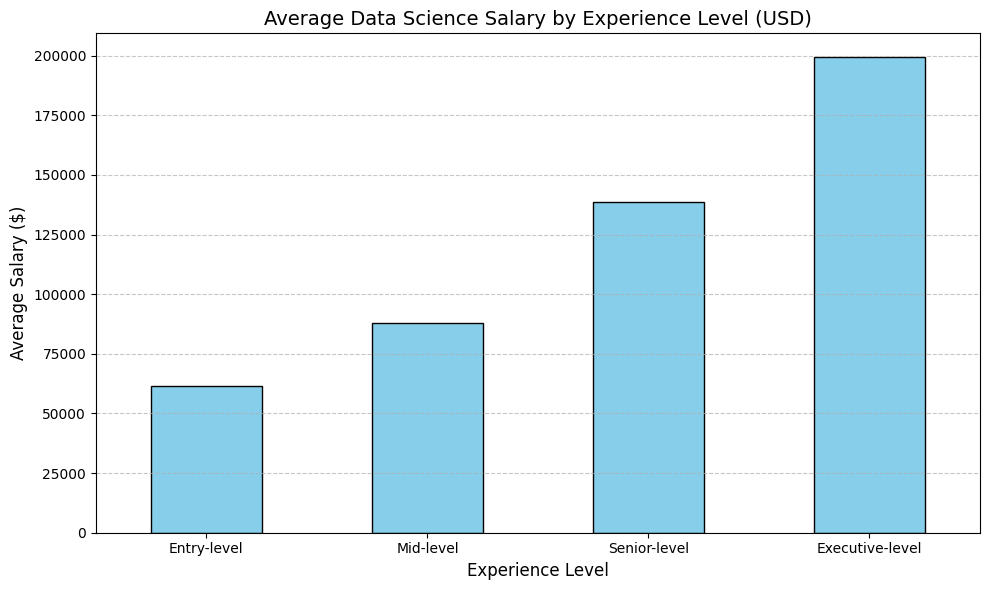

In [3]:
plt.figure(figsize=(10, 6))
salary_stats['mean'].plot(kind='bar', color='skyblue', edgecolor='black')

# Formatting the chart
plt.title('Average Data Science Salary by Experience Level (USD)', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Average Salary ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()